In [2]:
#setting up the notebook
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

In [ ]:
#reading the csv file
df= pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/BinX training/Project/data/medicaldataset.csv')

In [4]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


First i will do Kmeans for this datset for comparing

In [5]:
from sklearn.preprocessing import StandardScaler

X=df.drop('Result', axis=1)
scalar=StandardScaler()
X_scaled =scalar.fit_transform(X)

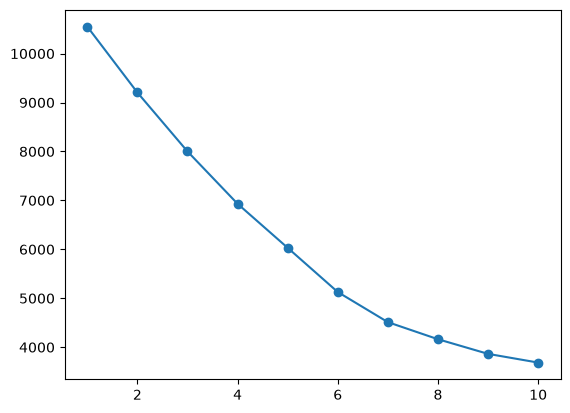

In [6]:
# finding the best k
from sklearn.cluster import KMeans
inertias = []

for k in range(1, 11):
 km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
 inertias.append(km.inertia_)
plt.plot(range(1, 11), inertias, marker="o") # look for the elbow

In [ ]:
#silhouette score for 5 clusters

from sklearn.metrics import silhouette_score


km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)
print(km.cluster_centers_) 

score = silhouette_score(X_scaled, labels)
score

[[ 1.38353802e-01 -1.39199109e+00 -5.12808825e-02 -1.53699626e-02
   2.41826155e-02 -3.71441365e-02 -1.52874927e-01 -1.82971732e-01]
 [-5.27176189e-01 -6.88528927e-01  2.00087092e+01  5.29602635e-01
   1.62032216e+00 -4.93595785e-01 -2.73254958e-01 -1.06363363e-02]
 [-7.98990265e-02  7.18395402e-01 -4.50155794e-02 -1.14800774e-03
  -2.11726052e-02  5.36779999e-03 -1.62216172e-01 -7.83972075e-02]
 [ 3.17393517e-01  7.61038608e-02  6.08719229e-02  2.51544936e-01
   1.45075351e-01 -1.25335011e-02 -2.16107349e-01  6.22710114e+00]
 [ 2.16511107e-02  1.23158186e-01 -5.86879593e-02  4.26868960e-03
  -2.83241611e-02  3.40396344e-01  5.26158767e+00 -4.83277662e-04]]


0.23867401034829455

In [8]:
#silhouette score for 6 clusters

km2 = KMeans(n_clusters=7, random_state=42, n_init=10)
labels2 = km2.fit_predict(X_scaled)
print(km2.cluster_centers_) 

score = silhouette_score(X_scaled, labels2)
score

[[-1.61376480e-01  5.20333239e-01 -4.45214644e-02  1.03078867e+00
   1.00530500e+00 -2.41418434e-01 -1.65816485e-01 -5.15278982e-02]
 [ 2.01240147e-01 -1.39199109e+00 -5.67617788e-02 -1.68712422e-01
  -1.20656385e-01 -2.51408559e-01 -1.47257657e-01 -1.83848930e-01]
 [ 2.16511107e-02  1.23158186e-01 -5.86879593e-02  4.26868960e-03
  -2.83241611e-02  3.40396344e-01  5.26158767e+00 -4.83277662e-04]
 [-6.26593410e-02  7.18395402e-01 -4.04939835e-02 -5.69997510e-01
  -5.50039068e-01 -3.15067940e-01 -1.49776998e-01 -1.14232250e-01]
 [-5.27176189e-01 -6.88528927e-01  2.00087092e+01  5.29602635e-01
   1.62032216e+00 -4.93595785e-01 -2.73254958e-01 -1.06363363e-02]
 [-2.73354701e-02  1.36792825e-01 -4.60367517e-02 -2.34187173e-02
  -1.64557606e-01  2.36536370e+00 -2.11577360e-01 -1.02383590e-02]
 [ 4.22262819e-01  1.15427833e-01  4.88372464e-02  1.53943274e-01
   1.81533563e-02 -1.21008872e-01 -2.08546467e-01  6.49634756e+00]]


0.2347091211068687

5 clusters is better with 0.238 silhouette score 

Text(0.5, 1.0, 'Kmeans Clusters')

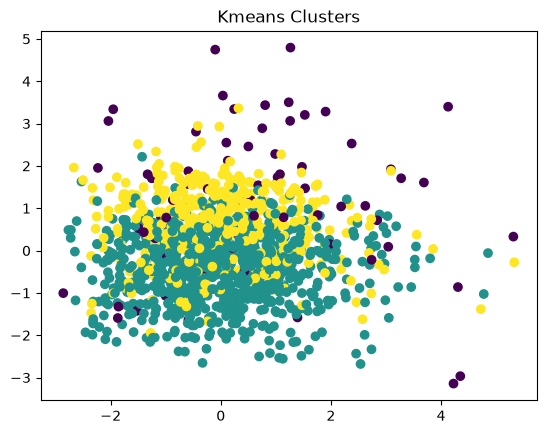

In [38]:
# making 2D df to plot
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)              
centers_2d = pca.transform(km.cluster_centers_)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title('Kmeans Clusters')

Model 2 : DBSCAN

In [34]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=2, min_samples=12)
labels = db.fit_predict(X_scaled)
# label -1 marks noise / outlier points

score = silhouette_score(X_scaled, labels)
score

0.2113474099588734

In [53]:
df['cluster']=labels
print(df['cluster'].value_counts())
n_clusters_db = df['cluster'].nunique() - (1)
print("number of clusters",  n_clusters_db)

cluster
 0    823
 1    421
-1     75
Name: count, dtype: int64
number of clusters 2


Text(0.5, 1.0, 'DBSCAN Clusters')

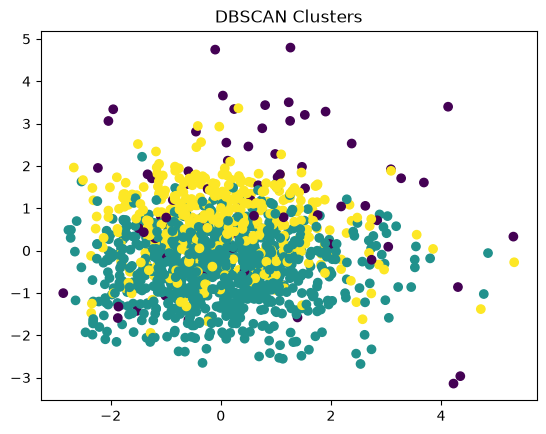

In [ ]:
# making 2D df to plot

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)             

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title('DBSCAN Clusters')

Model 3 :Hierarchical Clustering

0.8320482896359472

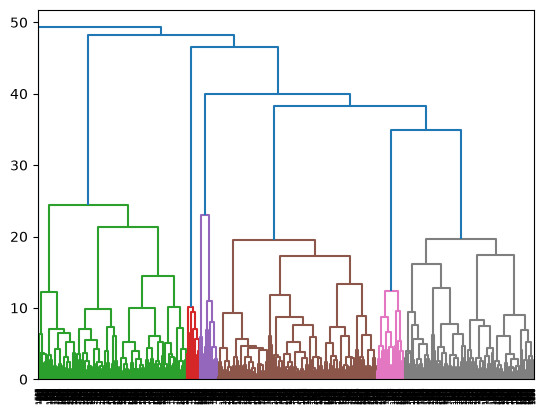

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_scaled, method="ward")
dendrogram(Z)   

hc_labels = fcluster(Z, t=2, criterion="maxclust")  
score = silhouette_score(X_scaled, hc_labels)
score

Text(0.5, 1.0, 'Hierarchical Clusters')

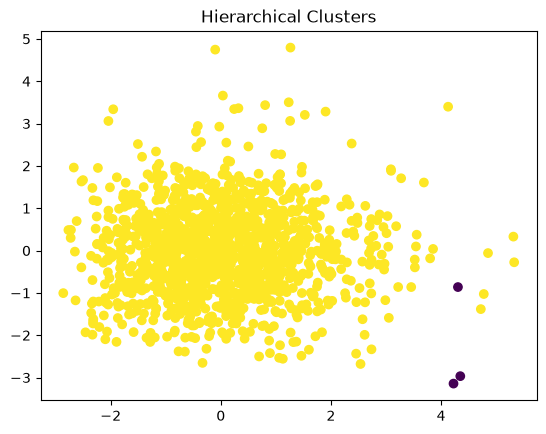

In [ ]:
# making 2D df to plot

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)              

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=hc_labels, cmap='viridis')
plt.title('Hierarchical Clusters')

 Which Method Fits Best

| Method       | Clusters | Noise | Silhouette |
|--------------|----------|-------|------------|
| K-Means      | 5        | 0     | 0.238      |
| DBSCAN       | 2        | 75    | 0.211      |
| Hierarchical | 2        | 0     | 0.832      |

K-Means gave the most reasonable result for this dataset. Its silhouette
score (0.238) was honest and not inflated by an uneven cluster split.

DBSCAN found 2 clusters and marked 75 points as noise/outliers — useful
for spotting unusual cases, but its score was close to K-Means, not better.

Hierarchical's high score (0.832) is misleading — cutting the tree at only
2 clusters likely produced one large cluster and one very small one, which
inflates silhouette artificially. It isn't a fair comparison at this cut.

this dataset doesn't form strong, well-separated natural
clusters (all fair scores sit around 0.2–0.25). K-Means is the most
reliable and interpretable choice here, but the data itself may not have
clean geometric groupings, even though it has a real clinical outcome
label.